In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.datasets import load_breast_cancer

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# 2. Scale the features
# Standardization is crucial here because features like 'mean area' and 'mean smoothness'
# operate on completely different numerical scales.

scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

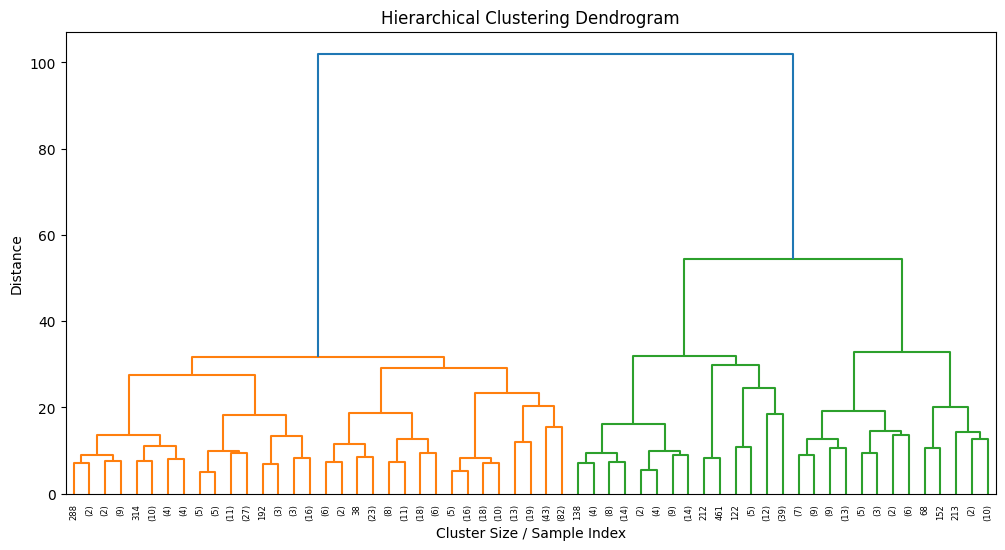

In [3]:
linked = linkage(x_scaled, method='ward')

plt.figure(figsize=(12, 6))
# Truncating the dendrogram slightly so the plot doesn't get overwhelmingly dense
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size / Sample Index')
plt.ylabel('Distance')
plt.show()

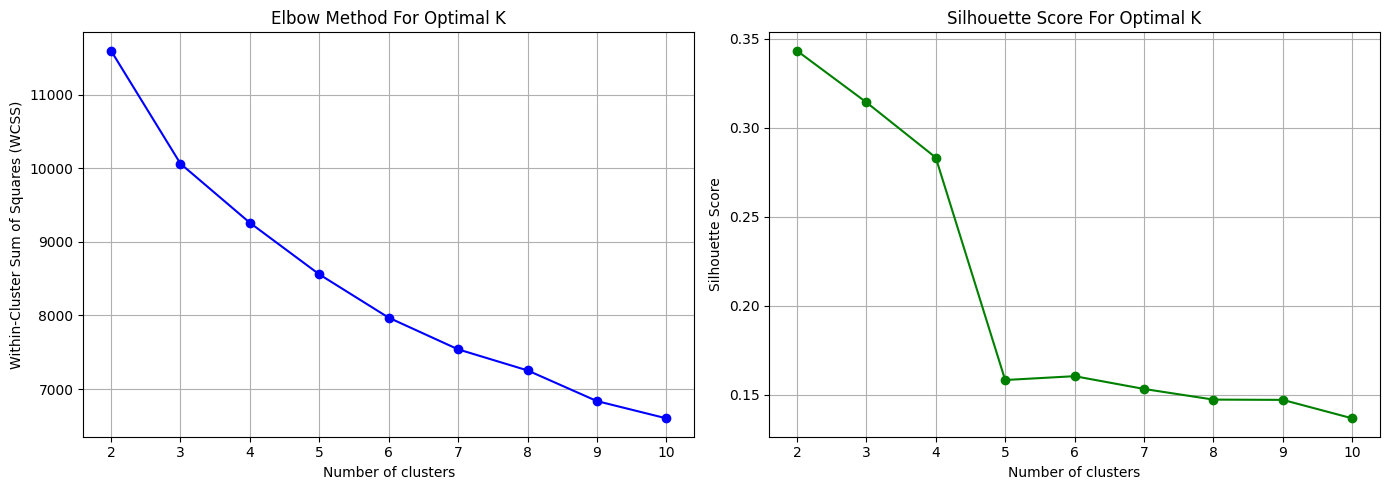

In [4]:
wcss = []
silhouette_avg = []
range_n_clusters = range(2, 11)

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(x_scaled, kmeans.labels_))

# 5. Plotting the evaluation metrics side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax1.plot(range_n_clusters, wcss, marker='o', color='blue')
ax1.set_title('Elbow Method For Optimal K')
ax1.set_xlabel('Number of clusters')
ax1.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax1.grid(True)

# Silhouette Score Plot
ax2.plot(range_n_clusters, silhouette_avg, marker='o', color='green')
ax2.set_title('Silhouette Score For Optimal K')
ax2.set_xlabel('Number of clusters')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [5]:
print("Silhouette Scores:", silhouette_avg)

Silhouette Scores: [0.34338224069077805, 0.3143840098608098, 0.28330544840954164, 0.15821041754355697, 0.16036705901249523, 0.15318636944468592, 0.1471945897553088, 0.1470399004571287, 0.13665610302995318]


In [6]:
from sklearn.cluster import AgglomerativeClustering

# Perform Agglomerative Clustering with 3 clusters
agglomerative_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
agglomerative_labels = agglomerative_model.fit_predict(x_scaled)

# Add the cluster labels to the original (scaled) DataFrame for visualization
df_scaled_clustered = pd.DataFrame(x_scaled, columns=data.feature_names)
df_scaled_clustered['agglomerative_cluster'] = agglomerative_labels

print("Agglomerative Cluster labels:")
print(pd.Series(agglomerative_labels).value_counts())

Agglomerative Cluster labels:
1    385
2    115
0     69
Name: count, dtype: int64


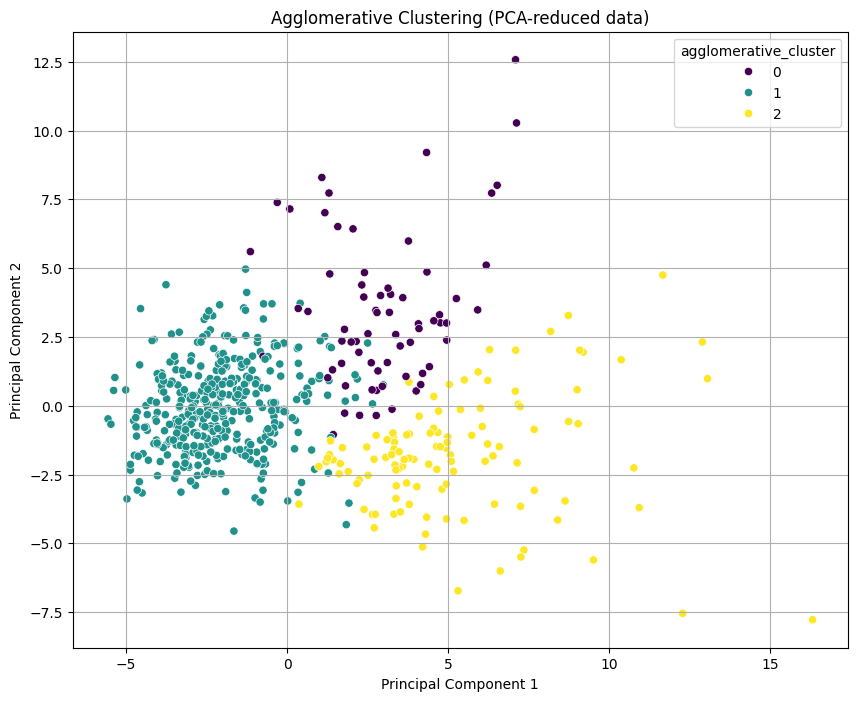

In [7]:
import seaborn as sns

# For visualization, we'll use PCA to reduce the dimensions to 2, as it's hard to visualize in >2 dimensions
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
df_pca['agglomerative_cluster'] = agglomerative_labels

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='agglomerative_cluster', data=df_pca, palette='viridis', legend='full')
plt.title('Agglomerative Clustering (PCA-reduced data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [8]:
silhouette_agg = silhouette_score(x_scaled, agglomerative_labels)
print(f"Silhouette Score for Agglomerative Clustering: {silhouette_agg:.4f}")

Silhouette Score for Agglomerative Clustering: 0.3301


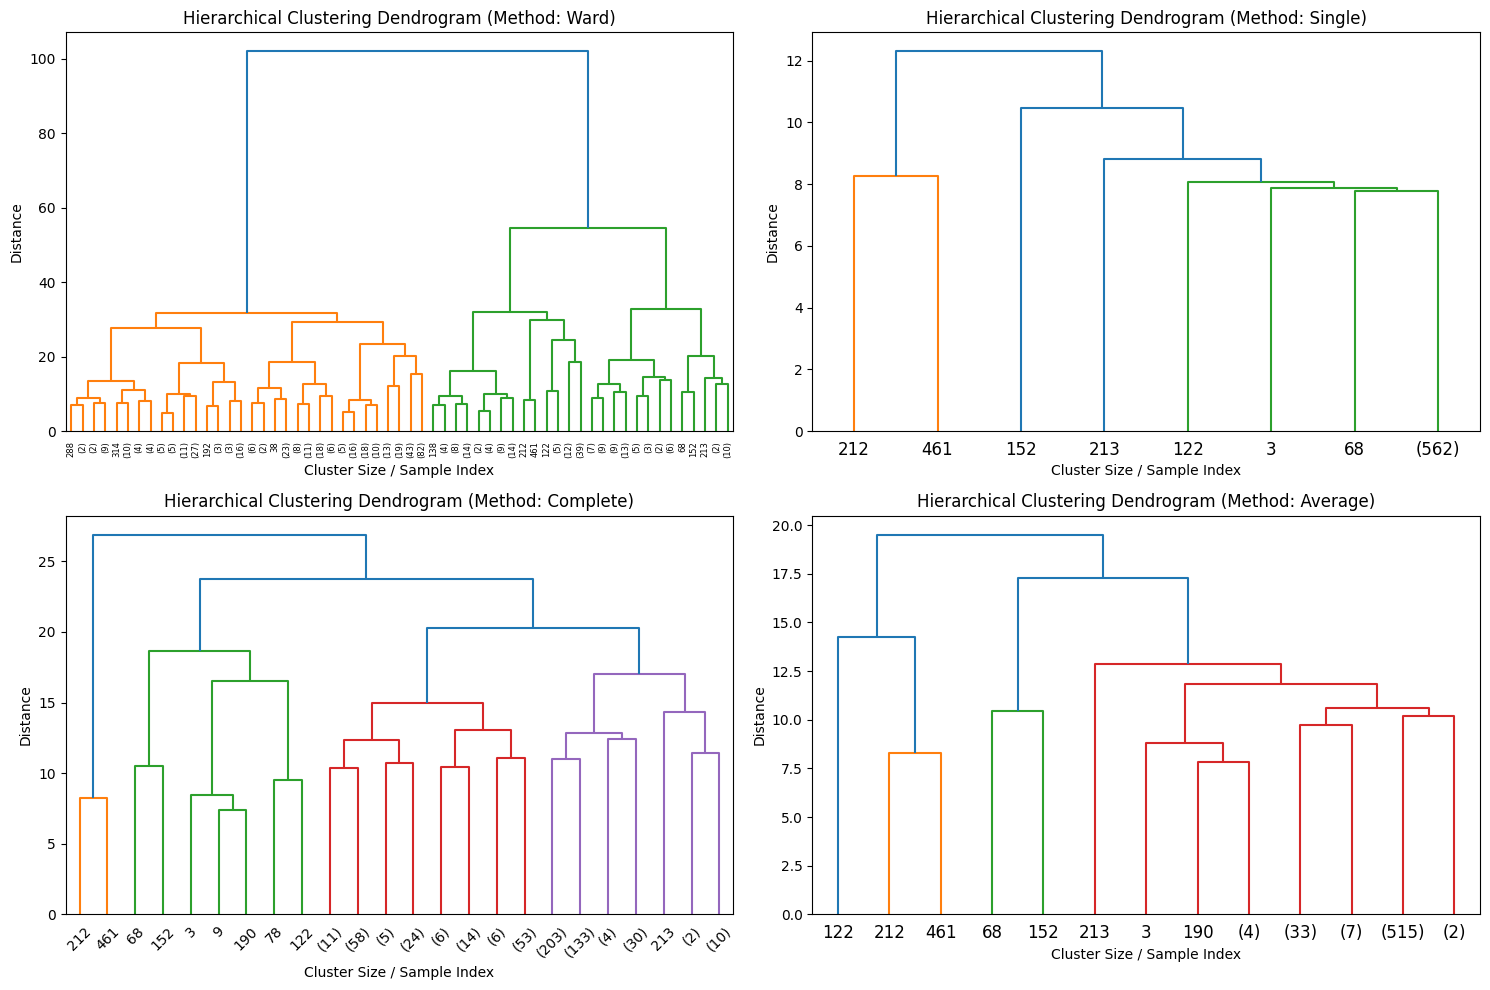

In [9]:
linkage_methods = ['ward', 'single', 'complete', 'average']

plt.figure(figsize=(15, 10))

for i, method in enumerate(linkage_methods):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    linked = linkage(x_scaled, method=method)
    dendrogram(linked,truncate_mode='level',p=5,show_leaf_counts=True,color_threshold=0.7 * max(linked[:,2])) # Color clusters below a certain threshold
    plt.title(f'Hierarchical Clustering Dendrogram (Method: {method.capitalize()})')
    plt.xlabel('Cluster Size / Sample Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'single', 'complete', 'average']
silhouette_scores_linkage = {}

for method in linkage_methods:
    # Perform Agglomerative Clustering with 3 clusters for each linkage method
    agglomerative_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage=method)
    agglomerative_labels = agglomerative_model.fit_predict(x_scaled)

    # Calculate silhouette score
    score = silhouette_score(x_scaled, agglomerative_labels)
    silhouette_scores_linkage[method] = score

print("Silhouette Scores for different linkage methods (with 3 clusters):")
for method, score in silhouette_scores_linkage.items():
    print(f"  {method.capitalize()} linkage: {score:.4f}")

Silhouette Scores for different linkage methods (with 3 clusters):
  Ward linkage: 0.3301
  Single linkage: 0.6356
  Complete linkage: 0.5450
  Average linkage: 0.5846
